---
title: "Geyser"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Old Faithful Geyser
- **description:** 272 eruptions of the Old Faithful geyser in Yellowstone, pairing each eruption's duration with the waiting time until the next one.
- **provenance:** The R `datasets::faithful` data (with a `kind` label added by seaborn); Azzalini, A. & Bowman, A. W. (1990), "A look at some data on the Old Faithful geyser," *Applied Statistics* 39(3), 357–365.
- **format:** long / tidy — 272 rows x 3 columns.

**Data dictionary**

- `duration` — *(measurement)* eruption length, in minutes.
- `waiting` — *(measurement)* time until the next eruption, in minutes.
- `kind` — *(identifier)* eruption type, `short` or `long`.

**Structure**

- **Rows:** 272 — one row per eruption.
- **Columns:** 3.
- **Identifiers:** `kind`.
- **Measurements:** `duration`, `waiting`.

**Use cases**

- bimodal distribution plots
- duration-vs-waiting scatter plots
- hexbin density of the two timing variables


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

### Long form (tidy)

In [6]:
geyser = sns.load_dataset('geyser')
geyser.info()
geyser

<class 'pandas.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duration  272 non-null    float64
 1   waiting   272 non-null    int64  
 2   kind      272 non-null    str    
dtypes: float64(1), int64(1), str(1)
memory usage: 6.5 KB


,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long
...,...,...,...
267,4.117,81,long
268,2.150,46,short
269,4.417,90,long
270,1.817,46,short


### Wide form

In [3]:
geyser1 = geyser.pivot_table(index='waiting', columns='kind', values='duration', aggfunc='mean')
geyser1

kind,long,short
waiting,,
43,NaN,1.983000
45,NaN,1.994667
46,NaN,1.883200
47,NaN,1.929250
48,NaN,1.928000
49,NaN,1.966800
50,NaN,2.137000
51,NaN,1.963833
52,NaN,1.900000


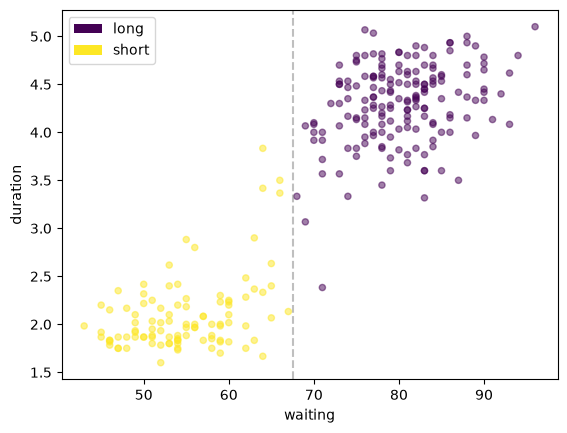

In [18]:
geyser.plot.scatter(x='waiting', y='duration', alpha=.5, c='kind')
plt.gca().axvline(67.5, ls='--', color='gray', alpha=.5)
plt.show()

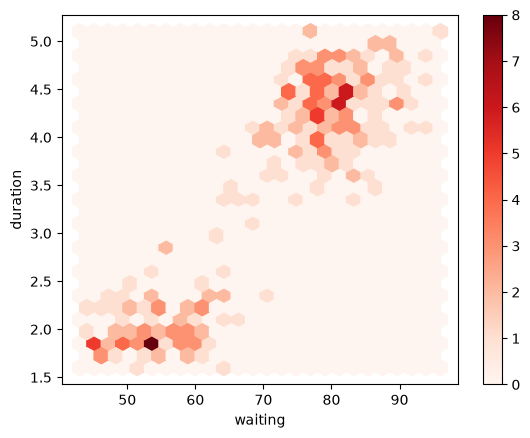

In [20]:
geyser.plot.hexbin(x='waiting', y='duration', gridsize=25, cmap='Reds')
plt.show()

The feature `kind` appears to be an after the fact labeling of a clusters.